# Assignment A1: Intro to Text Data, Tokenization, and Document Distance

Covering material from Notebooks 2, 3, 4

# Part A: Working with Text Data

In this assignment, we will explore how to load a text classification dataset (AG's news, originally posted [here](http://groups.di.unipi.it/~gulli/AG_corpus_of_news_articles.html)), how we can preprocess the data and extract useful information from a real-world dataset. First, we have to download the data; we only download a subset of the data with four classes.

In [4]:
!curl -O https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 28.1M  100 28.1M    0     0  23.7M      0  0:00:01  0:00:01 --:--:-- 23.7M


## Inspect Data

In [5]:
import pandas as pd
df = pd.read_csv("train.csv", header=None)
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   0       120000 non-null  int64
 1   1       120000 non-null  str  
 2   2       120000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 2.7 MB


,0,1,2
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


Let's make the data more human readable by adding a header and replacing labels

In [6]:
df.columns = ["label", "title", "lead"]
label_map = {1:"world", 2:"sport", 3:"business", 4:"sci/tech"}
def replace_label(x):
	return label_map[x]
df["label"] = df["label"].apply(replace_label) 

In [7]:
df.head()

,label,title,lead
0,business,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,business,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,business,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,business,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,business,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [9]:
df["text"] = (df["title"] + " " + df["lead"]).str.lower()


In [10]:
# TODO print the number of documents for each label
print(df["label"].value_counts())

label
business    30000
sci/tech    30000
sport       30000
world       30000
Name: count, dtype: int64


## Document Length

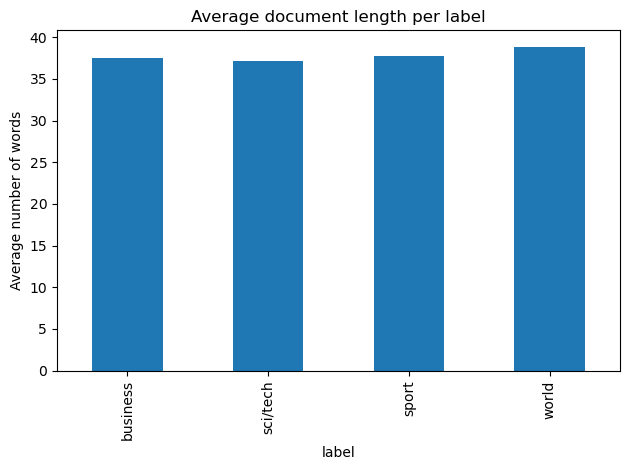

In [11]:
import matplotlib.pyplot as plt

# TODO create a new column with the number of words for each text
df["num_words"] = df["text"].str.split().str.len()

# TODO plot the average number of words per label
df.groupby("label")["num_words"].mean().plot(kind="bar")
plt.ylabel("Average number of words")
plt.title("Average document length per label")
plt.tight_layout()
plt.show()

## Word Frequency 

Let's implement a keyword search (similar to the baker-bloom economic uncertainty) and compute how often some given keywords ("play", "tax", "blackberry", "israel") appear in the different classes in our data

In [12]:
import re
keywords = ["play", "tax", "blackberry", "israel"]
for keyword in keywords:
    x = r'\b' + keyword + r'\b'
    pattern = re.compile(x)
    def count_keyword_frequencies(text, pat=pattern):
        num_occurrences = len(pat.findall(text))
        return num_occurrences
    # Now, we can print how often a keyword appears in the data
    print(df["text"].apply(count_keyword_frequencies).sum())
    # and we want to find out how often the keyword appears within each class
    for label in df["label"].unique():
        print("label:", label, ", keyword:", keyword)
        print(df[df["label"] == label]["text"].apply(count_keyword_frequencies).sum())
    print("*" * 100)

1802
label: business , keyword: play
72
label: sci/tech , keyword: play
220
label: sport , keyword: play
1431
label: world , keyword: play
79
****************************************************************************************************
1148
label: business , keyword: tax
923
label: sci/tech , keyword: tax
54
label: sport , keyword: tax
13
label: world , keyword: tax
158
****************************************************************************************************
228
label: business , keyword: blackberry
44
label: sci/tech , keyword: blackberry
184
label: sport , keyword: blackberry
0
label: world , keyword: blackberry
0
****************************************************************************************************
1485
label: business , keyword: israel
17
label: sci/tech , keyword: israel
36
label: sport , keyword: israel
32
label: world , keyword: israel
1400
****************************************************************************************************


As a last exercise, we re-use the fuzzy keyword search implemented above and plot the total number of occurrences of "tax" (and it's variations, e.g. taxation, taxes etc.) for each class in the dataset. Hint: have a look at the [pandas bar plot with group by](https://queirozf.com/entries/pandas-dataframe-plot-examples-with-matplotlib-pyplot)

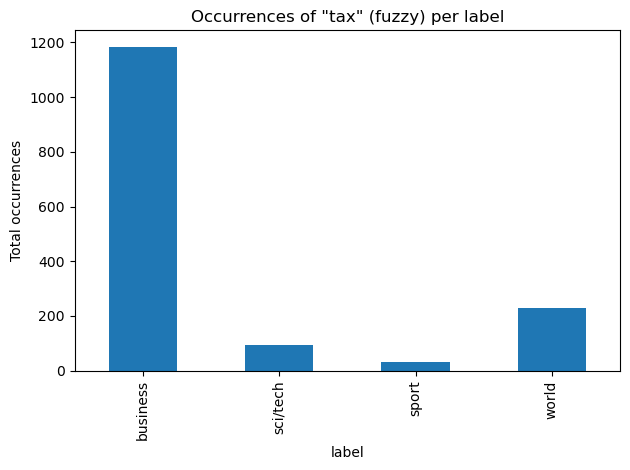

In [13]:
import matplotlib.pyplot as plt

keyword = "tax"
pattern = re.compile(r'\b' + keyword + r'\w*')

def count_keyword_frequencies(text):
    num_occurrences = len(pattern.findall(text))
    return num_occurrences

df["counts"] = df["text"].apply(count_keyword_frequencies)
#TODO create a bar plot for the wordcounts of "tax" for each class in the dataset
df.groupby("label")["counts"].sum().plot(kind="bar")
plt.ylabel("Total occurrences")
plt.title(f'Occurrences of "{keyword}" (fuzzy) per label')
plt.tight_layout()
plt.show()

# Part B: Tokenization

## Preprocess Text using spacy

In [14]:
import spacy
dfs = df.sample(200)
nlp = spacy.load('en_core_web_md')

## use spacy to split the documents in the sampled dataframe (dfs) in sentences and tokens
## use original (non-lowercased) text so capitalization is preserved
original_text = dfs["title"] + " " + dfs["lead"]
docs = list(nlp.pipe(original_text))

## print the first sentence of the first document in your sample
first_sent = list(docs[0].sents)[0]
print(first_sent)

Hurricane Ivan set to bring giant seas to Gulf of Mexico Surfersvillage Global Surf News, 13 September 2004: - - Hurricane Ivan, one of the most powerful storms to ever hit the Caribbean, killed at least 16 people in Jamaica, where it wrecked houses and washed away roads on Saturday, but appears to have spared


In [15]:
!pip install spacy
!python -m spacy download en_core_web_sm



import spacy
# more infos at https://spacy.io/
nlp = spacy.load('en_core_web_sm')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 15.0 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [16]:
import sys
!{sys.executable} -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 30.6 MB/s  0:00:01m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [17]:
## create a new column with tokens in lowercase, without punctuation nor stopwords
dfs = dfs.copy()
dfs["tokens"] = [
    [t.lower_ for t in doc if not t.is_punct and not t.is_stop]
    for doc in docs
]

## print the tokens (lemma) and tags of the first sentence of the first document
first_sent = list(docs[0].sents)[0]
for token in first_sent:
    print(token.lemma_, token.tag_)

Hurricane NNP
Ivan NNP
set VBD
to TO
bring VB
giant JJ
sea NNS
to IN
Gulf NNP
of IN
Mexico NNP
Surfersvillage NNP
Global NNP
Surf NNP
News NNP
, ,
13 CD
September NNP
2004 CD
: :
- :
- HYPH
Hurricane NNP
Ivan NNP
, ,
one CD
of IN
the DT
most RBS
powerful JJ
storm NNS
to TO
ever RB
hit VB
the DT
Caribbean NNP
, ,
kill VBN
at RB
least RBS
16 CD
people NNS
in IN
Jamaica NNP
, ,
where WRB
it PRP
wreck VBD
house NNS
and CC
wash VBD
away RP
road NNS
on IN
Saturday NNP
, ,
but CC
appear VBZ
to TO
have VB
spar VBN


### Noun Chunks

In [18]:
## print the first 20 noun chunks in the sample corpus
noun_chunks = [chunk for doc in docs for chunk in doc.noun_chunks]
for chunk in noun_chunks[:20]:
    print(chunk.text)

Hurricane Ivan
giant seas
Gulf
Mexico Surfersvillage Global Surf News
13 September
- - Hurricane Ivan
the most powerful storms
the Caribbean
at least 16 people
Jamaica
it
houses
roads
Saturday
Stocks
Thursday  NEW YORK
(Reuters
Stocks
Thursday
EXXON MOBIL


### Named Entities

Let's compute the ratio of named entities starting with a capital letter, e.g. if we have "University of Chicago" as a NE, "University" and "Chicago" are capitalized, "of" is not, thus the ratio is 2/3.

In [19]:
## ratio of tokens in named entity spans that start with a capital letter
ne_tokens = [token for doc in docs for ent in doc.ents for token in ent]
capitalized = [t for t in ne_tokens if t.text[0].isupper()]
print(len(capitalized) / len(ne_tokens))

0.6636280765724704


In [20]:
## ratio of capitalized tokens not being part of a named entity span
all_tokens = [token for doc in docs for token in doc]
capitalized_non_ne = [t for t in all_tokens if t.text[0].isupper() and not t.ent_type_]
print(len(capitalized_non_ne) / len(all_tokens))

0.07602872449561153


In [21]:
## ratio of capitalized tokens not in a NE span and not the first token in a sentence
capitalized_non_ne_non_sent_start = [
    t for t in all_tokens
    if t.text[0].isupper() and not t.ent_type_ and not t.is_sent_start
]
print(len(capitalized_non_ne_non_sent_start) / len(all_tokens))

0.05915878262851932


In [ ]:
for 

Give an example of a capitalized token in the data which is neither a named entity nor at the start of a sentence. What could be the reason the token is capitalized (one sentence)?

## Term Frequencies

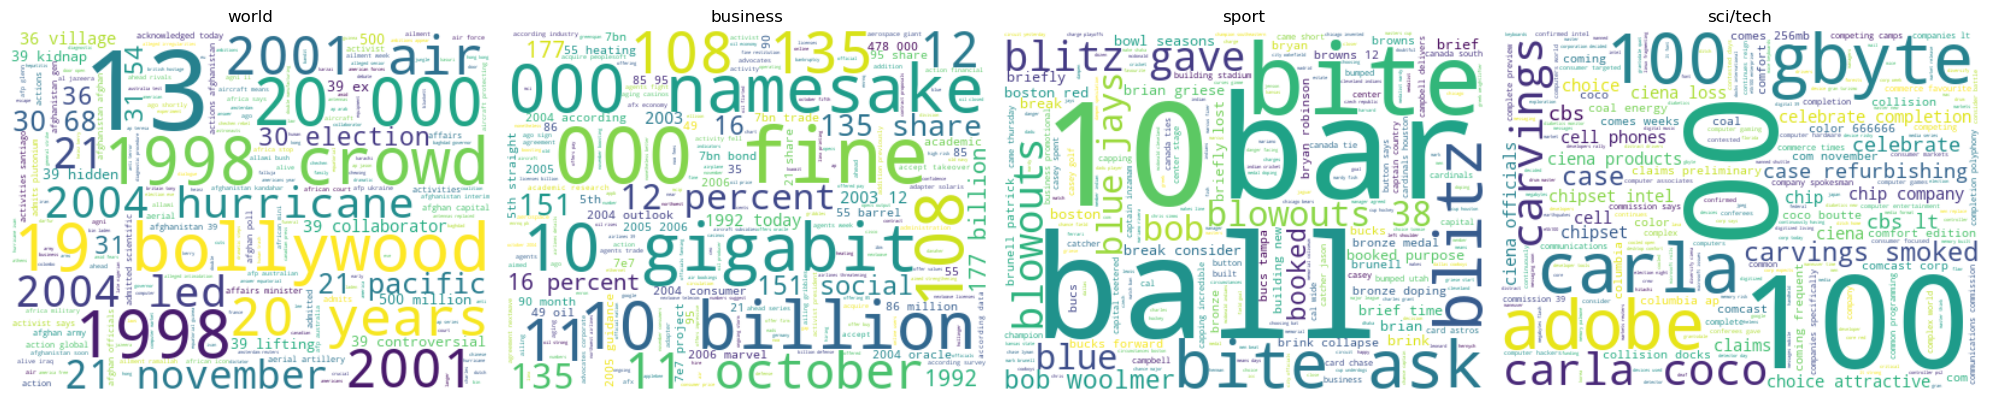

In [22]:
import sys
!{sys.executable} -m pip install wordcloud

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(min_df=0.01, 
                        max_df=0.9,  
                        max_features=1000,
                        stop_words='english',
                        use_idf=True,
                        ngram_range=(1,2))

from wordcloud import WordCloud
import matplotlib.pyplot as plt

## produce a word cloud with bigrams for each label using tfidf frequencies
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, label in zip(axes, dfs["label"].unique()):
    texts = dfs[dfs["label"] == label]["text"].tolist()
    tfidf.fit(texts)
    freqs = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))
    wc = WordCloud(width=400, height=300, background_color="white").generate_from_frequencies(freqs)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Hash Vectorizer

In [23]:
from sklearn.feature_extraction.text import HashingVectorizer

hv = HashingVectorizer(n_features=5000)

## print the first 10 features produced by the hash vectorizer
X = hv.transform(dfs["text"])
# HashingVectorizer has no vocabulary, so features are identified by their hash index
first_doc = X[0]
nonzero_indices = first_doc.nonzero()[1]
print("Feature index | Value")
for idx in nonzero_indices[:10]:
    print(f"  {idx:4d}        | {first_doc[0, idx]:.4f}")

Feature index | Value
    64        | -0.1170
   111        | -0.1170
   131        | -0.1170
   194        | -0.1170
   196        | 0.2341
   322        | -0.1170
   425        | 0.1170
   689        | 0.1170
   755        | 0.1170
   764        | 0.2341


## Supervised Feature Selection

In [24]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import SelectKBest, f_classif, chi2

## compute the number of words per document (excluding stopwords)
word_counts = dfs["tokens"].apply(len)
print(word_counts.describe())

## build a count matrix from pre-processed tokens for feature selection
cv_sel = CountVectorizer()
X_sel = cv_sel.fit_transform(dfs["tokens"].apply(" ".join))

## bin word counts into 3 quantile-based groups as classification target
y = pd.qcut(word_counts, q=3, labels=False)

## most predictive features using f_classif
selector_f = SelectKBest(f_classif, k=10).fit(X_sel, y)
print("f_classif top 10 features:")
print(cv_sel.get_feature_names_out()[selector_f.get_support()])

## most predictive features using chi2
selector_chi2 = SelectKBest(chi2, k=10).fit(X_sel, y)
print("\nchi2 top 10 features:")
print(cv_sel.get_feature_names_out()[selector_chi2.get_support()])

count    200.000000
mean      25.360000
std        7.536871
min        9.000000
25%       20.750000
50%       24.000000
75%       29.000000
max       55.000000
Name: tokens, dtype: float64
f_classif top 10 features:
['39' 'high' 'investor' 'new' 'reuters' 'states' 'stocks' 'test'
 'thursday' 'united']

chi2 top 10 features:
['fullquote' 'gt' 'investor' 'lt' 'quot' 'reuters' 'states' 'stocks'
 'test' 'united']


In [25]:

import spacy
# more infos at https://spacy.io/
nlp = spacy.load('en_core_web_sm')

Are the results different? What could be a reason for this? 

# C. Document Distance

In [26]:
from sklearn.feature_extraction.text import CountVectorizer

## vectorize the pre-processed text using CountVectorizer
# join the token lists back into strings for sklearn compatibility
cv = CountVectorizer()
X = cv.fit_transform(dfs["tokens"].apply(" ".join))
print(X.shape)

(200, 2657)


## Cosine Similarity

In [27]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

## compute cosine similarity matrix for the 200 snippets
sim_matrix = cosine_similarity(X)

## for the first snippet, find the 3 most similar (excluding itself)
sims = sim_matrix[0].copy()
sims[0] = -1  # mask self-similarity
top3_idx = np.argsort(sims)[-3:][::-1]

texts = dfs["text"].values
for rank, idx in enumerate(top3_idx, 1):
    print(f"Rank {rank} (similarity: {sim_matrix[0, idx]:.4f}):")
    print(texts[idx][:200])
    print()

Rank 1 (similarity: 0.1290):
dozens dead and missing in storms at least 64 people were killed and 65 missing in torrential storms lashing south-west china, disaster relief officials and state media said today.

Rank 2 (similarity: 0.0886):
retailers post modest gains in september new york oct. 7, 2004 - the outlook for the holiday shopping season grew more uncertain thursday as the nation #39;s largest retailers reported they had a four

Rank 3 (similarity: 0.0754):
paying for a storm that passed in 1992 today, as florida homeowners continue with the cleanup from their second big hurricane in less than a month, they are finding that they are bearing a greater sha



In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm



import spacy
# more infos at https://spacy.io/
nlp = spacy.load('en_core_web_sm')

  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached weasel-1.0.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached confection-1.3.3-py3-none-any.whl.metadata (19 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
  Using cached wrapt-2.1.2-cp311-cp311-macosx_11_0_arm64.whl.metadata (7.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 31.4 MB/s  0:00:00
Using cached catalogue-2.0.10-py3-non

## Clustering

Optimal k: 2, silhouette score: 0.2881


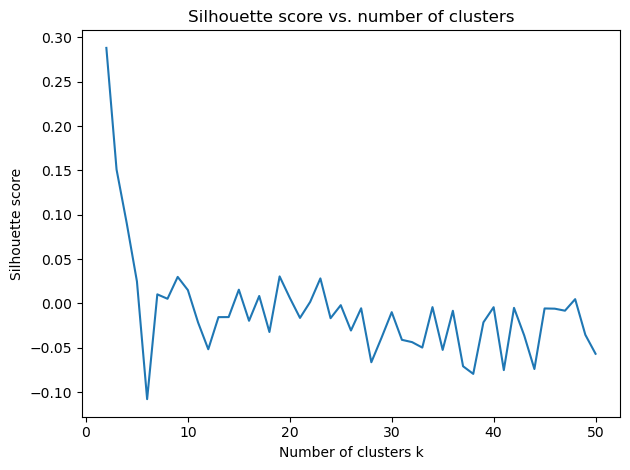

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# k=10 clustering
km10 = KMeans(n_clusters=10, random_state=42, n_init=10)
labels10 = km10.fit_predict(X)

# find optimal k using silhouette score
k_range = range(2, 51)
scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    scores.append(silhouette_score(X, labels))

optimal_k = list(k_range)[scores.index(max(scores))]
print(f"Optimal k: {optimal_k}, silhouette score: {max(scores):.4f}")

plt.plot(list(k_range), scores)
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score vs. number of clusters")
plt.tight_layout()
plt.show()

In [29]:
##TODO create the clusters using the opitmal number of clusters obtained before
##TODO compare the documents in cluster "1" under the two specifications, does the cluster look cleaner after having searched for the optimal number of clusters?

## create clusters using the optimal number of clusters
km_opt = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_opt = km_opt.fit_predict(X)

texts = dfs["text"].values

## compare documents in cluster 1 under both specifications
print(f"=== Cluster 1 with k=10 ({(labels10 == 1).sum()} docs) ===")
for t in texts[labels10 == 1]:
    print("-", t[:150])

print(f"\n=== Cluster 1 with k={optimal_k} ({(labels_opt == 1).sum()} docs) ===")
for t in texts[labels_opt == 1]:
    print("-", t[:150])

=== Cluster 1 with k=10 (1 docs) ===
- harvard pens some history philadelphia -- for 24 years, there had been nothing but nightmares for harvard's football team inside ben franklin's haunte

=== Cluster 1 with k=2 (4 docs) ===
- stocks to watch thursday  new york (reuters) - stocks moving on thursday: exxon mobil  &lt;a href="http://www.investor.reuters.com/fullquote.aspx?tick
- mci offers to pay part of states' claims  new york (reuters) - mci inc. &lt;a href="http://www.investor.reuters.com/fullquote.aspx?ticker=mcip.o targe
- applebee's sees room for more outlets  los angeles (reuters) - restaurant chain applebee's  international inc. &lt;a href="http://www.investor.reuters
- citigroup sued over enron securities  new york (reuters) - citigroup inc. &lt;a href="http://www.investor.reuters.com/fullquote.aspx?ticker=c.n target
